# 01e · Separación BCG/ICL — FoF local recortado a R₂₀₀c

**Diferencia respecto a los otros notebooks:**

| Notebook | Fuente | Partículas incluidas |
|----------|--------|----------------------|
| `01_` | `loadSubhalo(bcg_sub_idx)` | Solo subhalo central (Subfind) |
| `01b_` | `loadHalo(fof_idx)` + máscara | Central + no ligadas (todo el FoF) |
| `01d_` | API cutout FoF + máscara | Ídem 01b_, vía API |
| **`01e_`** | **`loadHalo(fof_idx)` + máscara + corte R₂₀₀c** | **Central + no ligadas, solo dentro de R₂₀₀c** |

**Motivación:** el perfil de Holmberg (μ_B = 26.5 mag/arcsec²) se define originalmente
dentro del radio del disco galáctico, pero para cúmulos masivos conviene limitar el análisis
a R₂₀₀c para excluir material que no está dinámicamente asociado al halo principal.

El flujo es idéntico a `01b_` hasta la máscara de satélites; luego se agrega un segundo
corte en distancia 3D: `r_3d <= R200c`.

In [1]:
import sys, os, pickle
import numpy as np
import h5py
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.stats import binned_statistic_2d
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, './original_shift_code')
import illustris_python as il
import Catalogue
import params_icl as P

FIG_PDF = './figuras/01e_BCG_ICL_R200_local/pdf'
FIG_PNG = './figuras/01e_BCG_ICL_R200_local/png'
os.makedirs(FIG_PDF, exist_ok=True)
os.makedirs(FIG_PNG, exist_ok=True)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 200,
                     'font.size': 12,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)

## Cargar catálogo + datos auxiliares del groupcat

In [2]:
with h5py.File(P.CATALOG_OUT, 'r') as f:
    group_idx     = f['group_idx'][:]       # índice FoF absoluto TNG
    M200c         = f['M200c_Msun'][:]
    R200c         = f['R200c_kpc'][:]
    GroupPos      = f['GroupPos_kpc'][:]
    bcg_sub_idx   = f['bcg_sub_idx'][:]
    t_last_merger = f['t_last_merger_Gyr'][:]
    dyn_state     = f['dyn_state'][:] if 'dyn_state' in f else None

n_cl = len(group_idx)
Header = il.groupcat.loadHeader(P.basePath, P.SNAP)

print("Cargando GroupNsubs, GroupFirstSub y SubhaloLenType...")
halo_cat = il.groupcat.loadHalos(P.basePath, P.SNAP,
                                  fields=['GroupNsubs', 'GroupFirstSub'])
GroupNsubs    = halo_cat['GroupNsubs']
GroupFirstSub = halo_cat['GroupFirstSub']

sub_cat        = il.groupcat.loadSubhalos(P.basePath, P.SNAP,
                                           fields=['SubhaloLenType', 'SubhaloMassType'])
SubhaloLenType = sub_cat['SubhaloLenType']   # (N_sub_total, 6)

print(f"Catálogo cargado: {n_cl} cúmulos")
print(f"Total subhalos: {len(SubhaloLenType):,}")

COLORS_STATE = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
LABELS_STATE = {0: 'Relajado', 1: 'Intermedio', 2: 'Perturbado'}

Cargando GroupNsubs, GroupFirstSub y SubhaloLenType...
Catálogo cargado: 166 cúmulos
Total subhalos: 4,371,211


In [3]:
sub_cat.keys()

dict_keys(['count', 'SubhaloLenType', 'SubhaloMassType'])

## Funciones auxiliares

In [4]:
def rotate_by_inertia_tensor(pos_rel, mass, r_lim=np.inf):
    """
    Alinea las partículas con los ejes principales del tensor de inercia reducido.
    Idéntica a la versión en los demás notebooks.
    """
    dist = np.linalg.norm(pos_rel, axis=1)
    ok   = (dist > 0) & (dist <= r_lim) & np.isfinite(mass)
    p, m = pos_rel[ok], mass[ok]

    if m.sum() == 0 or len(m) < 4:
        return pos_rel, np.eye(3)

    w    = 1.0 / dist[ok]**2
    mtot = np.sum(m)
    Ixx  = np.sum(m * p[:,0]**2 * w) / mtot
    Iyy  = np.sum(m * p[:,1]**2 * w) / mtot
    Izz  = np.sum(m * p[:,2]**2 * w) / mtot
    Ixy  = np.sum(m * p[:,0] * p[:,1] * w) / mtot
    Ixz  = np.sum(m * p[:,0] * p[:,2] * w) / mtot
    Iyz  = np.sum(m * p[:,1] * p[:,2] * w) / mtot
    I = np.array([[Ixx, Ixy, Ixz],
                  [Ixy, Iyy, Iyz],
                  [Ixz, Iyz, Izz]])

    eigvals, eigvecs = np.linalg.eigh(I)
    idx     = np.argsort(eigvals)[::-1]
    R_mat   = eigvecs[:, idx].T
    pos_rot = pos_rel @ R_mat.T
    return pos_rot, R_mat


def sb_profile_b(r_2d, lum_b, r_max_kpc, n_bins=60):
    """Perfil 1D de brillo superficial en banda B (Johnson, Vega)."""
    r_bins = np.logspace(np.log10(0.5), np.log10(r_max_kpc), n_bins + 1)
    r_mid  = np.sqrt(r_bins[:-1] * r_bins[1:])
    mu_b   = np.full(n_bins, np.nan)

    for k, (r1, r2) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mk = (r_2d >= r1) & (r_2d < r2)
        if mk.sum() == 0:
            continue
        area_pc2 = np.pi * ((r2 * 1e3)**2 - (r1 * 1e3)**2)
        sigma_L  = lum_b[mk].sum() / area_pc2
        if sigma_L > 0:
            mu_b[k] = P.SB_CONST - 2.5 * np.log10(sigma_L)

    return r_mid, mu_b


def sb_profile_smooth(r_2d, lum_r, r_max_kpc, n_bins=60, frac_sigma=0.15):
    """
    Perfil 1D de brillo superficial suavizado con kernel gaussiano.

    A diferencia de sb_profile_r (anillos de bordes duros y disjuntos), aquí
    cada punto r_mid[k] pondera TODAS las partículas con un peso gaussiano
    centrado en r_mid[k] y ancho frac_sigma*r_mid[k] (fraccional, escala con
    el radio igual que el espaciado logarítmico de r_bins). Las ventanas de
    puntos vecinos se solapan, lo que promedia el ruido de Poisson entre
    ellos y suaviza la curva — a costa de perder resolución radial fina y de
    correlacionar puntos vecinos (dejan de ser estadísticamente independientes).

    frac_sigma : ancho del kernel como fracción del radio (0.15 = ±15%).
    """
    r_bins = np.logspace(np.log10(0.5), np.log10(r_max_kpc), n_bins + 1)
    r_mid  = np.sqrt(r_bins[:-1] * r_bins[1:])
    mu_r   = np.full(n_bins, np.nan)

    for k, r0 in enumerate(r_mid):
        sigma_k = frac_sigma * r0
        if sigma_k <= 0:
            continue
        w = np.exp(-0.5 * ((r_2d - r0) / sigma_k) ** 2)
        if w.sum() == 0:
            continue
        area_pc2 = 2 * np.pi * r0 * sigma_k * 1e6   # área efectiva del anillo gaussiano, kpc→pc
        sigma_L  = np.sum(lum_r * w) / area_pc2
        if sigma_L > 0:
            mu_r[k] = P.SB_CONST - 2.5 * np.log10(sigma_L)

    return r_mid, mu_r


def holmberg_radius(r_mid, mu_b, mu_cut=P.MU_HOLMBERG):
    """Interpola el radio donde μ_B = mu_cut."""
    valid = np.isfinite(mu_b) & (r_mid > 0)
    if valid.sum() < 3:
        return np.nan
    r_v, m_v = r_mid[valid], mu_b[valid]
    idx_s = np.argsort(r_v)
    r_v, m_v = r_v[idx_s], m_v[idx_s]
    if m_v[0] > mu_cut or m_v[-1] < mu_cut:
        return np.nan
    try:
        f = interp1d(m_v, r_v, kind='linear', fill_value='extrapolate')
        r_h = float(f(mu_cut))
        return r_h if 0 < r_h <= r_v[-1] * 1.2 else np.nan
    except Exception:
        return np.nan

## Función principal: FoF local → máscara satélites → corte R₂₀₀c

El pipeline tiene tres pasos:
1. `loadHalo` — carga todas las estrellas del FoF
2. Máscara de satélites (igual que `01b_`) — excluye subhalos 1..N-1
3. **Corte esférico en R₂₀₀c** — descarta partículas con distancia 3D al BCG > R₂₀₀c

In [5]:
def build_fof_mask_no_satellites(fof_idx):
    """
    Calcula las longitudes estelares de cada subhalo del FoF (subhalo 0 = central,
    1..N-1 = satélites). Idéntica a la lógica de 01b_.

    Retorna:
        lens_star    : array (n_subs,) — N° partículas estelares por subhalo
        n_central    : int — estrellas del subhalo central
        n_satellites : int — estrellas en subhalos satélites (1..N-1)
    """
    first_sub = GroupFirstSub[fof_idx]
    n_subs    = GroupNsubs[fof_idx]

    if n_subs > 0:
        lens_star = SubhaloLenType[first_sub : first_sub + n_subs, 4].astype(int)
    else:
        lens_star = np.array([], dtype=int)

    total_in_subhalos = int(lens_star.sum())
    n_central    = int(lens_star[0]) if len(lens_star) > 0 else 0
    n_satellites = total_in_subhalos - n_central

    return lens_star, n_central, n_satellites


def mask_from_lens(lens_star, n_total_fof, exclude_satellites=True):
    """
    Máscara booleana sobre las partículas estelares del FoF:
      True  = subhalo 0 (central) + no ligadas  (+ satélites si exclude_satellites=False)
      False = satélites 1..N-1  (solo si exclude_satellites=True)
    Función idéntica a la de 01b_/01d_.
    """
    if not exclude_satellites:
        return np.ones(n_total_fof, dtype=bool)
    mask = np.zeros(n_total_fof, dtype=bool)
    n_central = int(lens_star[0]) if len(lens_star) > 0 else n_total_fof
    mask[:n_central] = True
    total_in_subhalos = int(lens_star.sum())
    if total_in_subhalos < n_total_fof:
        mask[total_in_subhalos:] = True
    return mask


def bcg_icl_mass_fraction_r200(fof_idx, cen_pos, r200_kpc, header=Header,
                                exclude_satellites=True):
    """
    Carga el FoF local, (opcionalmente) excluye satélites, recorta a R₂₀₀c,
    y devuelve (f_ICL, M_BCG, M_ICL) en M☉.
    """
    try:
        fields = ['Coordinates', 'Masses', 'GFM_StellarPhotometrics']
        st = il.snapshot.loadHalo(P.basePath, P.SNAP, int(fof_idx), 'stars',
                                   fields=fields)
        if isinstance(st, int) or st is None:
            return np.nan, np.nan, np.nan
        n_total = len(st['Masses'])
        if n_total == 0:
            return np.nan, np.nan, np.nan

        # 1. Convertir unidades y centrar
        pos_raw = Catalogue.Distance_3D(
            st['Coordinates'] * P.UL, cen_pos, header['BoxSize'] * P.UL)
        mass_raw = st['Masses'] * P.UM
        phot_raw = st['GFM_StellarPhotometrics']
        if phot_raw.ndim == 1:
            phot_raw = phot_raw.reshape(-1, 8)

        # 2. Máscara de satélites (incluir o excluir según exclude_satellites)
        lens_star, *_ = build_fof_mask_no_satellites(fof_idx)
        mask_sat = mask_from_lens(lens_star, n_total, exclude_satellites=exclude_satellites)

        # 3. Corte esférico en R₂₀₀c
        r_3d     = np.linalg.norm(pos_raw, axis=1)
        mask_r200 = r_3d <= r200_kpc

        mask_final = mask_sat & mask_r200

        pos  = pos_raw[mask_final]
        mass = mass_raw[mask_final]
        phot = phot_raw[mask_final]
        # índice 1 = B-band (Johnson, Vega)
        lum  = 10**((P.M_SUN_B_VEGA - phot[:, 1]) / 2.5)

        pos_rot, _ = rotate_by_inertia_tensor(pos, mass)
        r_2d = np.sqrt(pos_rot[:,0]**2 + pos_rot[:,1]**2)

        #r_m, mu = sb_profile_b(r_2d, lum, np.percentile(r_2d, 99))
        r_m, mu = sb_profile_smooth(r_2d, lum, np.percentile(r_2d, 99))
        
        r_h = holmberg_radius(r_m, mu)
        if not np.isfinite(r_h):
            return np.nan, np.nan, np.nan

        m_bcg = mass[r_2d <= r_h].sum()
        m_icl = mass[r_2d >  r_h].sum()
        m_tot = m_bcg + m_icl
        return (m_icl / m_tot, m_bcg, m_icl) if m_tot > 0 else (np.nan, np.nan, np.nan)

    except Exception as e:
        print(f"    [WARN] fof_idx={fof_idx}  error: {e}")
        return np.nan, np.nan, np.nan


## Demostración con un cúmulo

Mismo cúmulo demo que los demás notebooks (el más masivo, `group_idx=0`) para poder comparar directamente.

In [6]:
EXCLUDE_SATELLITES = False   # False = conserva satélites (compara con 01d_/01b_ exclude_satellites=False)

i_demo   = 0
fof_demo = int(group_idx[i_demo])
cen      = GroupPos[i_demo]
r200     = R200c[i_demo]

print(f"Cúmulo demo: local i={i_demo}, fof_idx TNG={fof_demo}")
print(f"log M200c = {np.log10(M200c[i_demo]):.2f}  R200c = {r200:.1f} kpc")
print(f"exclude_satellites = {EXCLUDE_SATELLITES}")
print()

# Cargar todas las estrellas del FoF
fields  = ['Coordinates', 'Masses', 'GFM_StellarPhotometrics']
st_fof  = il.snapshot.loadHalo(P.basePath, P.SNAP, fof_demo, 'stars', fields=fields)
n_fof_total = len(st_fof['Masses'])

# Convertir unidades y centrar en el BCG
pos_raw  = Catalogue.Distance_3D(
    st_fof['Coordinates'] * P.UL, cen, Header['BoxSize'] * P.UL)
mass_raw = st_fof['Masses'] * P.UM
phot_raw = st_fof['GFM_StellarPhotometrics']
if phot_raw.ndim == 1:
    phot_raw = phot_raw.reshape(-1, 8)

# Paso 1: máscara de satélites (incluir o excluir según EXCLUDE_SATELLITES)
lens_star, n_central, n_sat = build_fof_mask_no_satellites(fof_demo)
mask_sat = mask_from_lens(lens_star, n_fof_total, exclude_satellites=EXCLUDE_SATELLITES)

# Paso 2: corte esférico en R₂₀₀c (distancia 3D al BCG)
r_3d      = np.linalg.norm(pos_raw, axis=1)
mask_r200 = r_3d <= r200

# usar solo dentro de R200
# mask_final = mask_sat & mask_r200

# usar todo el FoF
mask_final = mask_sat 


n_excl_r200 = mask_sat.sum() - mask_final.sum()   # dentro de máscara sat pero fuera de R200


Cúmulo demo: local i=0, fof_idx TNG=0
log M200c = 14.58  R200c = 1523.0 kpc
exclude_satellites = False



In [7]:
print(f"Stellar particles:")
print(f"  Total FoF                  : {n_fof_total:>9,}")
print(f"  Satélites {'excluidos' if EXCLUDE_SATELLITES else 'incluidos '}      : {n_sat:>9,}")
print(f"  BCG (+ satélites si aplica): {mask_sat.sum():>9,}")
print(f"  Excluidas por R₂₀₀c        : {n_excl_r200:>9,}")
print(f"  Usadas para perfil (01e_)  : {mask_final.sum():>9,}")

Stellar particles:
  Total FoF                  : 11,816,696
  Satélites incluidos       : 7,823,406
  BCG (+ satélites si aplica): 11,816,696
  Excluidas por R₂₀₀c        :         0
  Usadas para perfil (01e_)  : 11,816,696


In [8]:
# Aplicar máscara final y calcular luminosidades
pos  = pos_raw[mask_final]
mass = mass_raw[mask_final]
phot = phot_raw[mask_final]
# índice 1 = B-band (Johnson, Vega) en GFM_StellarPhotometrics (U,B,V,K,g,r,i,z)
lum_b = 10**((P.M_SUN_B_VEGA - phot[:, 1]) / 2.5)

# Rotar al plano del eje mayor
pos_rot, R_mat = rotate_by_inertia_tensor(pos, mass)
r_2d = np.sqrt(pos_rot[:, 0]**2 + pos_rot[:, 1]**2)

# Perfil de brillo superficial
r_max    = np.percentile(r_2d, 99)
#r_mid, mu_b = sb_profile_b(r_2d, lum_b, r_max)
r_mid, mu_b = sb_profile_smooth(r_2d, lum_b, r_max)


# Radio de Holmberg
r_h = holmberg_radius(r_mid, mu_b)

# Separación BCG/ICL
M_bcg_demo = mass[r_2d <= r_h].sum()
M_icl_demo = mass[r_2d >  r_h].sum()
f_icl_demo = M_icl_demo / (M_bcg_demo + M_icl_demo)

print(f"Radio de Holmberg : {r_h:.1f} kpc")
print(f"M_BCG             : {M_bcg_demo:.3e} M_sun  (log = {np.log10(M_bcg_demo):.2f})")
print(f"M_ICL             : {M_icl_demo:.3e} M_sun  (log = {np.log10(M_icl_demo):.2f})")
print(f"f_ICL (R₂₀₀c)     : {f_icl_demo:.3f}")

# Comparar con 01b_ (FoF completo)
try:
    with h5py.File(P.CATALOG_OUT, 'r') as f:
        if 'icl_frac_fof' in f:
            f_icl_01b = f['icl_frac_fof'][i_demo]
            print(f"\nComparación con 01b_ (FoF completo):")
            print(f"  f_ICL_FoF (01b_)    : {f_icl_01b:.3f}")
            print(f"  f_ICL_R200 (01e_)   : {f_icl_demo:.3f}")
            print(f"  Δ                   : {f_icl_demo - f_icl_01b:+.3f}")
except Exception:
    pass

Radio de Holmberg : 346.8 kpc
M_BCG             : 4.143e+12 M_sun  (log = 12.62)
M_ICL             : 6.901e+12 M_sun  (log = 12.84)
f_ICL (R₂₀₀c)     : 0.625

Comparación con 01b_ (FoF completo):
  f_ICL_FoF (01b_)    : 0.241
  f_ICL_R200 (01e_)   : 0.625
  Δ                   : +0.384


### Figura 1 – Perfil de brillo superficial 1D

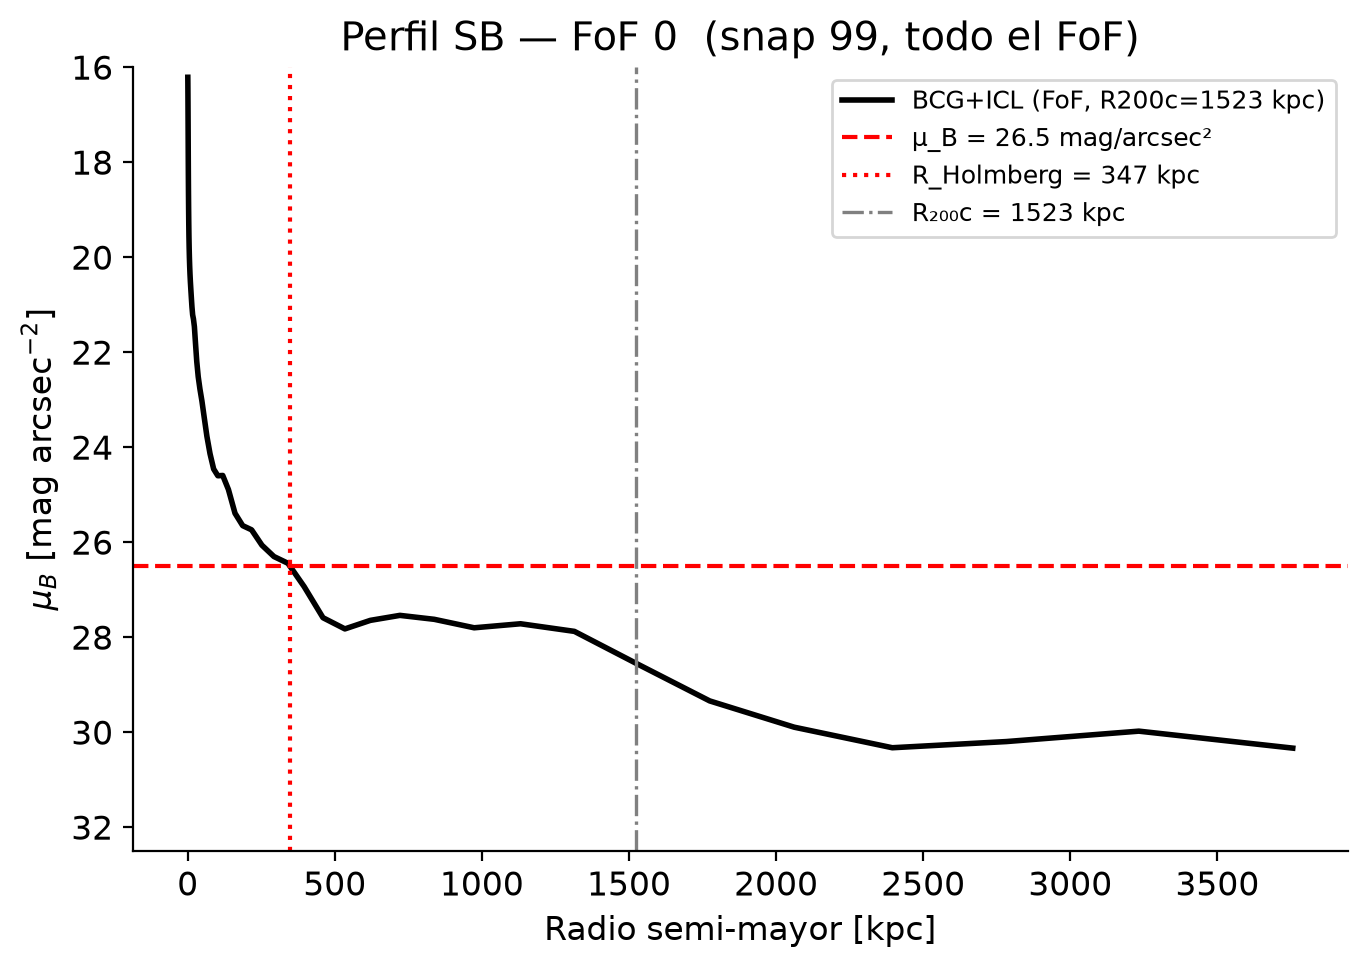

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(mu_b)

# R < R200
#ax.plot(r_mid[valid], mu_b[valid], 'k-', lw=2,
#        label=f'BCG+ICL (FoF, R < R₂₀₀c={r200:.0f} kpc)')


ax.plot(r_mid[valid], mu_b[valid], 'k-', lw=2,
        label=f'BCG+ICL (FoF, R200c={r200:.0f} kpc)')


ax.axhline(P.MU_HOLMBERG, color='r', ls='--', lw=1.5,
           label=f'μ_B = {P.MU_HOLMBERG} mag/arcsec²')
if np.isfinite(r_h):
    ax.axvline(r_h, color='r', ls=':', lw=1.5,
               label=f'R_Holmberg = {r_h:.0f} kpc')
    #ax.fill_betweenx([mu_b[valid].min()-1, P.MU_HOLMBERG+4],
    #                  0, r_h, alpha=0.10, color='royalblue', label='BCG')
    #ax.fill_betweenx([mu_b[valid].min()-1, P.MU_HOLMBERG+4],
    #                  r_h, r_mid[valid][-1], alpha=0.10, color='tomato', label='ICL')
ax.axvline(r200, color='gray', ls='-.', lw=1.2,
           label=f'R₂₀₀c = {r200:.0f} kpc')
ax.set_ylim(32.5, 16)
ax.set_xlabel('Radio semi-mayor [kpc]')
ax.set_ylabel(r'$\mu_B$ [mag arcsec$^{-2}$]')

# recortando a r200 
#ax.set_title(f'Perfil SB — FoF {fof_demo}  (snap {P.SNAP}, recortado a R₂₀₀c)')

# sin recortar a r200 con todos los satelites
ax.set_title(f'Perfil SB — FoF {fof_demo}  (snap {P.SNAP}, todo el FoF)')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01e_perfil_sb_fof{fof_demo}_snap{P.SNAP}.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01e_perfil_sb_fof{fof_demo}_snap{P.SNAP}.png', bbox_inches='tight', dpi=150)
plt.show()

### Figura 2 – Mapa 2D de brillo superficial

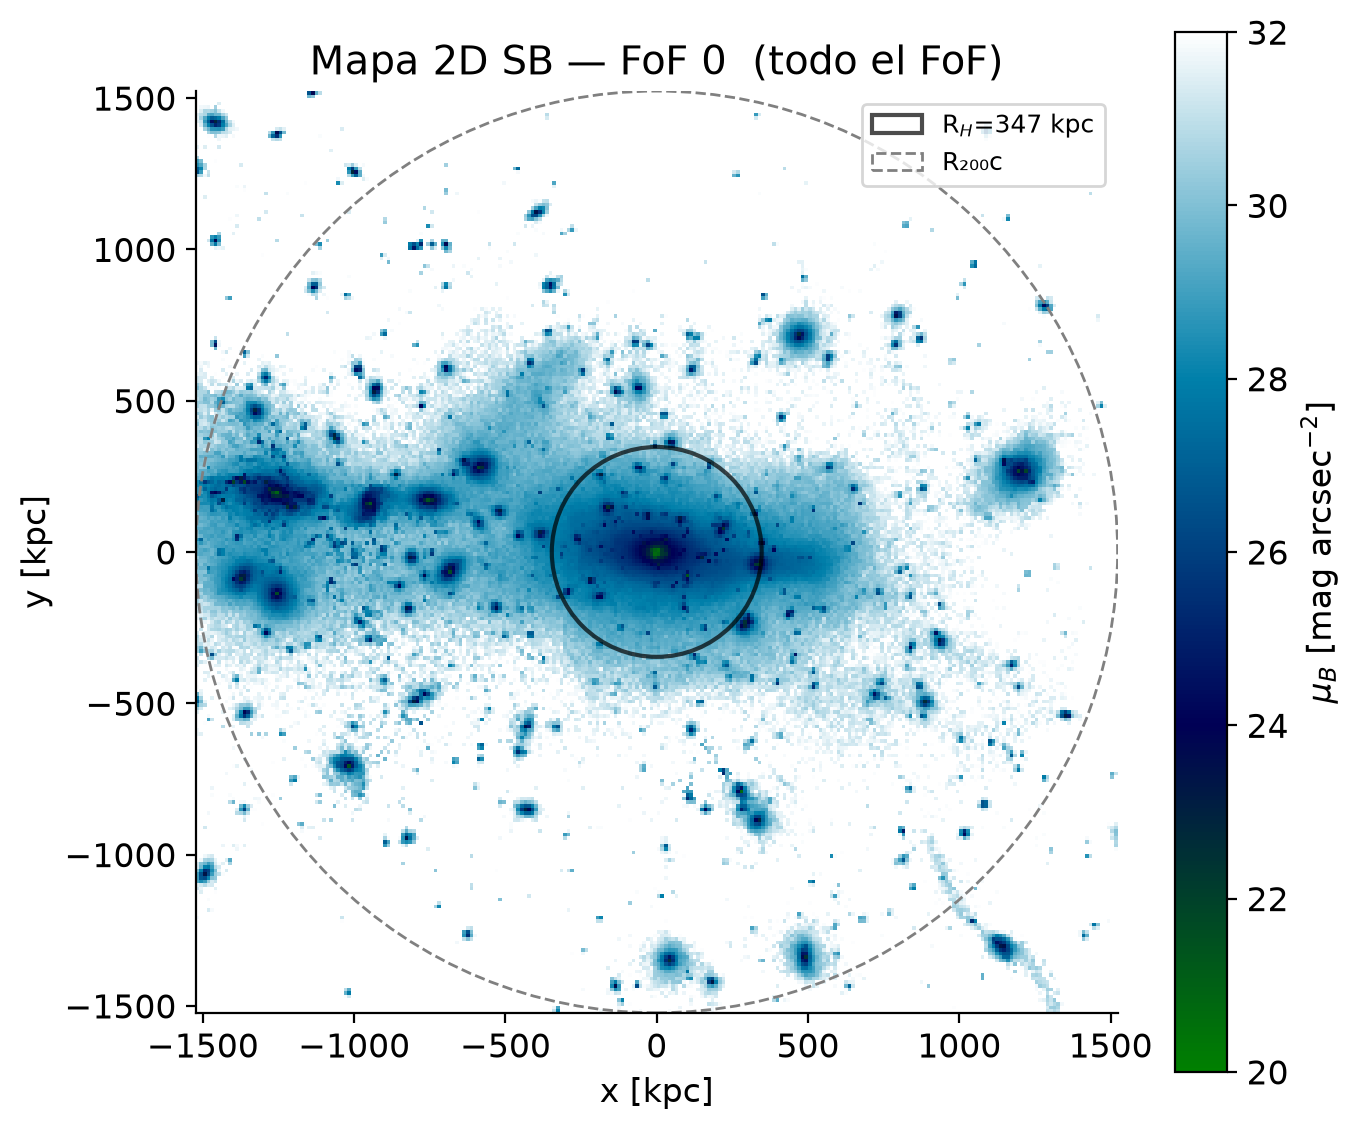

In [10]:
r_plot  = r200
n_pix   = 256
edges   = np.linspace(-r_plot, r_plot, n_pix + 1)
pix_pc2 = ((2 * r_plot / n_pix) * 1e3)**2

H, _, _, _ = binned_statistic_2d(pos_rot[:, 0], pos_rot[:, 1],
                                   lum_b, statistic='sum',
                                   bins=[edges, edges])
with np.errstate(divide='ignore', invalid='ignore'):
    sigma  = np.where(H > 0, H / pix_pc2, np.nan)
    mu_map = np.where(sigma > 0, P.SB_CONST - 2.5 * np.log10(sigma), np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mu_map.T, origin='lower', cmap='ocean',
               extent=[-r_plot, r_plot, -r_plot, r_plot],
               vmin=20, vmax=32)
plt.colorbar(im, ax=ax, label=r'$\mu_B$ [mag arcsec$^{-2}$]')
if np.isfinite(r_h):
    ax.add_patch(plt.Circle((0, 0), r_h, fill=False, color='black',
                              lw=1.5, label=f'R$_H$={r_h:.0f} kpc', alpha=0.7))
ax.add_patch(plt.Circle((0, 0), r200, fill=False, color='gray',
                          lw=1, ls='--', label='R₂₀₀c'))
ax.set_xlabel('x [kpc]'); ax.set_ylabel('y [kpc]')

# recortado en R200
# ax.set_title(f'Mapa 2D SB — FoF {fof_demo}  (R < R200)')

# sin recorte a R200
ax.set_title(f'Mapa 2D SB — FoF {fof_demo}  (todo el FoF)')

ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01e_mapa_sb_fof{fof_demo}_snap{P.SNAP}.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01e_mapa_sb_fof{fof_demo}_snap{P.SNAP}.png', bbox_inches='tight', dpi=150)
plt.show()

---------------------------------

## Calcular f_ICL (R₂₀₀c) para todos los cúmulos

In [ ]:
icl_frac_r200 = np.full(n_cl, np.nan)
M_bcg_r200    = np.full(n_cl, np.nan)
M_icl_r200    = np.full(n_cl, np.nan)

print(f"Calculando fracciones de masa ICL (versión R₂₀₀c, exclude_satellites={EXCLUDE_SATELLITES})...")
for i in range(n_cl):
    fof_i = int(group_idx[i])
    icl_frac_r200[i], M_bcg_r200[i], M_icl_r200[i] = \
        bcg_icl_mass_fraction_r200(fof_i, GroupPos[i], R200c[i],
                                    exclude_satellites=EXCLUDE_SATELLITES)
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{n_cl}  f_ICL_med={np.nanmedian(icl_frac_r200[:i+1]):.3f}",
              end="\r")

n_ok  = np.sum(np.isfinite(icl_frac_r200))
n_nan = n_cl - n_ok
print(f"\n  Completados: {n_ok}/{n_cl}  ({n_nan} con NaN)")

try:
    with h5py.File(P.CATALOG_OUT, 'a') as f:
        for k, v in [('icl_frac_r200',  icl_frac_r200),
                     ('M_bcg_r200_Msun', M_bcg_r200),
                     ('M_icl_r200_Msun', M_icl_r200)]:
            if k in f:
                del f[k]
            f.create_dataset(k, data=v)
    print(f"Guardado en: {P.CATALOG_OUT}")
    print(f"  f_ICL_R200 = {np.nanmean(icl_frac_r200):.3f} ± {np.nanstd(icl_frac_r200):.3f}")
except Exception as e:
    print(f"[ERROR] No se pudo guardar: {e}")


Calculando fracciones de masa ICL (versión R₂₀₀c, exclude_satellites=False)...


### Figura 3 – f_ICL (R₂₀₀c) vs M₂₀₀c

In [ ]:
def linfit(x, y, log_x=True):
    xx = np.log10(x) if log_x else np.asarray(x)
    yy = np.asarray(y)
    ok = np.isfinite(xx) & np.isfinite(yy)
    sl, ic, *_ = linregress(xx[ok], yy[ok])
    return sl, ic, xx[ok], yy[ok]

lM = np.log10(M200c)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if dyn_state is not None:
    for s in [0, 1, 2]:
        m = dyn_state == s
        ax.scatter(lM[m], icl_frac_r200[m], color=COLORS_STATE[s],
                   label=LABELS_STATE[s], s=20, alpha=0.75)
else:
    ax.scatter(lM, icl_frac_r200, color='steelblue', s=20, alpha=0.75)

sl, ic, lx, ly = linfit(M200c, icl_frac_r200)
xx = np.linspace(lx.min(), lx.max(), 100)
ax.plot(xx, sl*xx+ic, 'k-', lw=1.8, label=f'β = {sl:.3f}')
ax.set_xlabel(r'$\log_{10}(M_{200c}\,/\,M_\odot)$')
ax.set_ylabel(r'$f_{\rm ICL}$ (R < R₂₀₀c)')
ax.set_title('Fracción ICL — versión R₂₀₀c')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(icl_frac_r200[np.isfinite(icl_frac_r200)], bins=20,
        color='steelblue', edgecolor='white', lw=0.5)
ax.axvline(np.nanmedian(icl_frac_r200), ls='--', color='k', lw=1.5,
           label=f'Mediana = {np.nanmedian(icl_frac_r200):.3f}')
ax.set_xlabel(r'$f_{\rm ICL}$ (R < R₂₀₀c)')
ax.set_ylabel('N cúmulos')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01e_icl_r200_vs_masa.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01e_icl_r200_vs_masa.png', bbox_inches='tight', dpi=150)
plt.show()

### Figura 4 – Comparación: f_ICL (FoF completo, 01b_) vs f_ICL (R < R₂₀₀c, 01e_)

In [ ]:
try:
    with h5py.File(P.CATALOG_OUT, 'r') as f:
        icl_frac_fof = f['icl_frac_fof'][:] if 'icl_frac_fof' in f else None
except Exception:
    icl_frac_fof = None

if icl_frac_fof is not None:
    valid = np.isfinite(icl_frac_fof) & np.isfinite(icl_frac_r200)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    sc = ax.scatter(icl_frac_fof[valid], icl_frac_r200[valid],
                    c=lM[valid], cmap='viridis', s=25, alpha=0.8)
    plt.colorbar(sc, ax=ax, label=r'$\log M_{200c}$')
    lim = [0, max(icl_frac_fof[valid].max(), icl_frac_r200[valid].max()) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1, label='1:1')
    ax.set_xlabel(r'$f_{\rm ICL}$ (FoF completo, 01b\_)')
    ax.set_ylabel(r'$f_{\rm ICL}$ (R < R₂₀₀c, 01e\_)')
    ax.set_title('Comparación: FoF completo vs recortado a R₂₀₀c')
    ax.legend(fontsize=9)

    ax = axes[1]
    delta = icl_frac_r200[valid] - icl_frac_fof[valid]
    ax.hist(delta, bins=25, color='tomato', edgecolor='white', lw=0.5)
    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.axvline(np.median(delta), color='red', lw=1.5,
               label=f'Mediana Δ = {np.median(delta):.3f}')
    ax.set_xlabel(r'$f_{\rm ICL,R200} - f_{\rm ICL,FoF}$')
    ax.set_ylabel('N cúmulos')
    ax.set_title('Diferencia R₂₀₀c − FoF completo')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{FIG_PDF}/fig01e_comparacion_r200_vs_fof.pdf', bbox_inches='tight')
    plt.savefig(f'{FIG_PNG}/fig01e_comparacion_r200_vs_fof.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Δf_ICL medio (R200 − FoF): {np.mean(delta):.4f} ± {np.std(delta):.4f}")
    print(f"Cúmulos donde R200 > FoF : {(delta > 0).sum()} / {valid.sum()}")
else:
    print("No se encontró 'icl_frac_fof'. Corre primero 01b_separacion_BCG_ICL_FoF.ipynb.")

### Figura 5 – f_ICL (R₂₀₀c) vs tiempo desde el último merger mayor

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(t_last_merger) & np.isfinite(icl_frac_r200)
sc = ax.scatter(t_last_merger[valid], icl_frac_r200[valid],
                c=lM[valid], cmap='viridis', s=25, alpha=0.8)
plt.colorbar(sc, ax=ax, label=r'$\log M_{200c}$')
sl, ic, tx, ty = linfit(t_last_merger[valid], icl_frac_r200[valid], log_x=False)
xx = np.linspace(tx.min(), tx.max(), 100)
ax.plot(xx, sl*xx+ic, 'k-', lw=1.8, label=f'β = {sl:.3f}')
ax.set_xlabel('Lookback time desde último merger mayor [Gyr]')
ax.set_ylabel(r'$f_{\rm ICL}$ (R < R₂₀₀c)')
ax.set_title('Fracción ICL (R₂₀₀c) vs Tiempo merger')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01e_icl_r200_vs_merger.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01e_icl_r200_vs_merger.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"β = {sl:.3f}")